In [34]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import deque
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "nbformat"])
from pathlib import Path

pi = np.pi

In [10]:
def sim_instance(
        seed = None,
        sim_len = 200000, # in timesteps
        memory_len = 10,
        replay_archive_len = 5000,
        n_hidden = 64,
        epsilon = 0.1,
        gamma = 0.95,
        alpha = 0.01,
        death_penalty = -5,
        batch_size = 32,
        update_ticks = 50,
        replay_warmup = 500,
        learn_every = 1,
        eval_len = 10000,
        check_eval_states = False
):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    ideal_h = 1
    ideal_s = 1
    day_length = 50 # ticks

    h = ideal_h
    s = ideal_s

    drink_amount = 0.15
    eat_amount = 0.3

    action_effects = np.array([
    [0.0, 0.0],    # 0 wait
    [1.0, 0.0],    # 1 drink full
    [0.5, 0.0],    # 2 drink half
    [0.25, 0.0],   # 3 drink quarter
    [0.0, 1.0],    # 4 eat full
    [0.0, 0.5],    # 5 eat half
    [0.0, 0.25],   # 6 eat quarter
    [0.5, 0.5],    # 7 drink half + eat half
])

    positions1 = np.arange(1, 8)
    weights1 = (11 - positions1) ** 2
    proportions1 = weights1 / weights1.sum()

    positions2 = np.arange(1, 11)
    ##weights2 = positions2 ** 2
    proportions2 = positions2 / positions2.sum()

    r_que = deque(maxlen=replay_archive_len)
    m_que_d = deque([0] * memory_len, maxlen=memory_len)
    m_que_e = deque([0] * memory_len, maxlen=memory_len)
    a_que = deque(maxlen=11)

    n_act = len(action_effects)
    n_input = 3 + len(m_que_e) + len(m_que_d)

    carry_x = ()
    carry_act = 0

    # Layer 1: Scale by sqrt(2 / n_input)
    w1 = np.random.randn(n_input, n_hidden) * np.sqrt(2 / n_input)
    b1 = np.zeros(n_hidden)

    # Layer 2: Scale by sqrt(2 / n_hidden)
    w2 = np.random.randn(n_hidden, n_act) * np.sqrt(2 / n_hidden)
    b2 = np.zeros(n_act)

    w1_t, b1_t, w2_t, b2_t = w1.copy(), b1.copy(), w2.copy(), b2.copy()

    lifetime_stats = [[], [], [], [], [], [], [], [], []]
    death_events = []

    eval_boundary = sim_len - eval_len
    eval_zeros = [0] * memory_len
    eval_states = {
        "thirsty":   np.array([0.2, 1.0, 0.5, *eval_zeros, *eval_zeros]),
        "hungry":    np.array([1.0, 0.2, 0.5, *eval_zeros, *eval_zeros]),
        "desperate": np.array([0.2, 0.2, 0.5, *eval_zeros, *eval_zeros]),
        "overfull":  np.array([1.5, 1.5, 0.5, *eval_zeros, *eval_zeros]),
    }

    def get_brightness(time, day_len=100):
        a = 0.5
        b = 0.3
        c = (2*pi) / day_len
        
        brightness = a + b*np.sin(c*time)
        brightness += np.random.normal(0, 0.05)
        return np.clip(brightness, 0, 1)

    def decay_hydration(hydration, satiation, brightness):
        decay = max(0, (0.15*brightness) - (0.03*satiation))
        decay += np.random.normal(0.05, 0.03)
        return hydration - decay
    
    def decay_satiation(satiation, hydration, brightness):
        decay = max(0, ((0.05 - 0.05*brightness) + (0.04 - 0.04*hydration) + 0.1*(ideal_h - hydration)))        
        decay += np.random.normal(0.01, 0.005)
        return satiation - decay
    
    def the_meaning_of_life(hydration, satiation):
        h_dist = hydration - ideal_h
        s_dist = satiation - ideal_s

        d2 = h_dist**2 + s_dist**2

        return 2 * np.exp(-3 * d2) - 1
    
    def forward_pass(x):
        hidden = np.maximum(0, (x @ w1) + b1)  # ReLU
        output = (hidden @ w2) + b2

        return output, hidden
    
    def forward_pass_t(x):
        hidden = np.maximum(0, (x @ w1_t) + b1_t)  
        output = (hidden @ w2_t) + b2_t

        return output, hidden

    for t in range(sim_len):
        b = get_brightness(t, day_length)
        h = decay_hydration(h, s, b)
        s = decay_satiation(s, h, b)

        for age, act in enumerate(a_que):
            drink_choice, eat_choice = action_effects[act]

            if age < len(proportions1):
                h += drink_amount * drink_choice * proportions1[age] * (0.8 + 0.3*s) 

            if age < len(proportions2):
                s += eat_amount * eat_choice * proportions2[age]

        h = np.clip(h, 0, 2)
        s = np.clip(s, 0, 2)

        cur_comfort = the_meaning_of_life(h, s)
        cur_dead = int((h <= 0.05) or (s <= 0.05))
        cur_reward = cur_comfort + death_penalty * cur_dead

        if cur_dead and t != 0:
            if h <= 0.05 and s <= 0.05:
                death_cause = "both"
            elif h <= 0.05:
                death_cause = "hydration"
            else:
                death_cause = "satiation"

            death_events.append({
                "t": t,
                "cause": death_cause,
                "h": h,
                "s": s,
            })

        cur_x = np.array([h, s, b, *m_que_d, *m_que_e])

        if t != 0: # dont learn if we dont know anything
            r_que.append((carry_x, carry_act, cur_reward, cur_x, bool(cur_dead)))

            if t % learn_every == 0 and len(r_que) >= replay_warmup:
                if t % (update_ticks * learn_every) == 0:
                    w1_t, b1_t, w2_t, b2_t = w1.copy(), b1.copy(), w2.copy(), b2.copy()

                batch = random.sample(r_que, min(batch_size, len(r_que)))
                nb = len(batch)
            
                state = np.array([transition[0] for transition in batch])   # all 32 cur states
                action = np.array([transition[1] for transition in batch])   # all 32 actions
                reward = np.array([transition[2] for transition in batch])   # all 32 rewards
                next_state = np.array([transition[3] for transition in batch])   # all 32 next states
                done = np.array([transition[4] for transition in batch], dtype=bool)

                alive = ~done
                
                target_output, _ = forward_pass_t(next_state) # batch, n_act
                target = reward + ( gamma*np.max(target_output, axis=1) )*alive  # batch,  (future only matters if ur alive)

                q_values, hidden = forward_pass(state) # batch, n_act and batch, 64
                q_action = q_values[np.arange(nb), action] # batch,

                err_out = np.zeros((nb, n_act)) # nb, n_act

                err_out[np.arange(nb), action] = target - q_action # nb, n_act (shape not changed)
                d_w2 = hidden.T @ err_out # n_hidden, nb @ nb, n_act > n_hidden, n_act (matches weight's shape)
                err_hidden = (err_out @ w2.T) * (hidden != 0) # nb, n_act @ n_act, n_hidden > nb, n_hidden * n_hidden, > nb, n_hidden
                d_w1 = state.T @ err_hidden # n_input, nb @ nb, n_hidden > n_input, n_hidden (matches weight's shape)

                b2 += alpha * err_out.mean(axis=0)
                w2 += alpha * d_w2 / nb
                b1 += alpha * err_hidden.mean(axis=0)
                w1 += alpha * d_w1 / nb
            
            #region old loop for Back prop
            '''
            # back propagate
            batch = random.sample(r_que, min(batch_size, len(r_que)))
            for transition in batch:

                next_x = transition[n_act]
                target_output, _ = forward_pass_t(next_x)
                target = transition[2] + gamma*np.max(target_output)

                x = transition[0]
                action_taken = transition[1]
                q_values, hidden = forward_pass(x)
                q_action = q_values[action_taken]

                err_out = np.eye(3)[action_taken] * (target - q_action)
                d_w2 = hidden.reshape(n_hidden, 1) @ err_out.reshape(1, n_act) # n_hidden, 1 @ 1, n_act > n_hidden, n_act
                error_at_hidden = (w2 @ err_out) * (hidden != 0) # mask for relu: n_hidden, n_act @ n_act,  > n_hidden,
                d_w1 = x.reshape(n_input, 1) @ error_at_hidden.reshape(1, n_hidden)  # n_input, 1 @ 1, n_hidden > n_input, n_hidden

                acc_b2 += np.clip(err_out, -1, 1)
                acc_w2 += np.clip(d_w2, -1, 1) 
                acc_b1 += np.clip(error_at_hidden, -1, 1)
                acc_w1 += np.clip(d_w1, -1, 1)
                
        b2 += alpha * acc_b2 / batch_size
        w2 += alpha * acc_w2 / batch_size
        b1 += alpha * acc_b1 / batch_size
        w1 += alpha * acc_w1 / batch_size
        '''
        #endregion
        
        log_h = h
        log_s = s
        log_m_d = list(m_que_d)
        log_m_e = list(m_que_e)

        if cur_dead:
            angle = np.random.uniform(0, 2*np.pi)
            radius = np.sqrt(np.random.uniform(0.3**2, 0.6**2))   # note to self i should take jacobian if i want even distrbution
            h = ideal_h + radius * np.cos(angle)
            s = ideal_s + radius * np.sin(angle)
            a_que.clear()
            m_que_d.clear()
            m_que_e.clear()
            m_que_d.extend([0] * memory_len)
            m_que_e.extend([0] * memory_len)
            cur_x = np.array([h, s, b, *m_que_d, *m_que_e])

        if np.random.uniform(0, 1) < epsilon and t < eval_boundary: # MrTakeThatRisk
            action = np.random.randint(0, n_act)

        else: # actually think then decide action
            cur_qvals, _ = forward_pass(cur_x)
            action = np.argmax(cur_qvals)

        a_que.appendleft(action)

        m_que_d.appendleft(action_effects[action, 0])
        m_que_e.appendleft(action_effects[action, 1])

        carry_x = cur_x
        carry_act = action

        lifetime_stats[0].append(cur_comfort)
        lifetime_stats[1].append(action)
        lifetime_stats[2].append([log_m_d, log_m_e])
        lifetime_stats[3].append(log_h)
        lifetime_stats[4].append(log_s)
        lifetime_stats[5].append(b)
        lifetime_stats[7].append(cur_reward)
        lifetime_stats[8].append(cur_dead)

        if check_eval_states:
            cur_eval_state_q = []
            for name, state in eval_states.items():
                q, _ = forward_pass(state)
                cur_eval_state_q.append(q)
            lifetime_stats[6].append(cur_eval_state_q)

    lifetime_comfort = np.array(lifetime_stats[0])
    lifetime_action = np.array(lifetime_stats[1])
    lifetime_memory = np.array(lifetime_stats[2])
    lifetime_hydration = np.array(lifetime_stats[3])
    lifetime_satiation = np.array(lifetime_stats[4])
    lifetime_brightness = np.array(lifetime_stats[5])
    
    lifetime_reward = np.array(lifetime_stats[7])
    death_T = np.array(lifetime_stats[8])

    return {
        "comfort_T" :    lifetime_comfort,
        "action_T" :     lifetime_action,
        "memory_T" :     lifetime_memory,
        "hydration_T" :  lifetime_hydration,
        "satiation_T" :  lifetime_satiation,
        "brightness_T" : lifetime_brightness,

        "comfort_train" :    lifetime_comfort[ :eval_boundary],
        "action_train" :     lifetime_action[ :eval_boundary],
        "memory_train" :     lifetime_memory[ :eval_boundary],
        "hydration_train" :  lifetime_hydration[ :eval_boundary],
        "satiation_train" :  lifetime_satiation[ :eval_boundary],
        "brightness_train" : lifetime_brightness[ :eval_boundary],

        "comfort_eval" :    lifetime_comfort[eval_boundary: ],
        "action_eval" :     lifetime_action[eval_boundary: ],
        "memory_eval" :     lifetime_memory[eval_boundary: ],
        "hydration_eval" :  lifetime_hydration[eval_boundary: ],
        "satiation_eval" :  lifetime_satiation[eval_boundary: ],
        "brightness_eval" : lifetime_brightness[eval_boundary: ],

        "mean_comfort" :   lifetime_comfort[eval_boundary: ].mean(),
        "min_comfort" :    lifetime_comfort[eval_boundary: ].min(),
        "std_comfort" :    lifetime_comfort[eval_boundary: ].std(),
        "mean_hydration" : lifetime_hydration[eval_boundary: ].mean(),
        "mean_satiation" : lifetime_satiation[eval_boundary: ].mean(),

        "reward_T": lifetime_reward,
        "reward_train": lifetime_reward[:eval_boundary],
        "reward_eval": lifetime_reward[eval_boundary:],
        "mean_reward": lifetime_reward[eval_boundary:].mean(),
        "min_reward": lifetime_reward[eval_boundary:].min(),
        "max_reward": lifetime_reward[eval_boundary:].max(),
        "std_reward": lifetime_reward[eval_boundary:].std(),

        "death_T" : death_T,
        "death_events": death_events,
        "death_count" : death_T.sum(),
        "death_rate" : death_T.mean(),
        "death_count_eval": death_T[eval_boundary:].sum(),
        "death_rate_eval": death_T[eval_boundary:].mean(),
    }

In [72]:
#region COST SINGLE TEST
'''
import cProfile

prof = cProfile.Profile()
run = prof.runcall(sim_instance, seed=42)
prof.print_stats(sort="tottime")

c = run["comfort_eval"]
x = np.arange(len(c)) + len(run["comfort_train"])
running_mean = np.cumsum(c) / np.arange(1, len(c) + 1)

plt.figure(figsize=(10, 4))
plt.plot(x, running_mean)
plt.axhline(c.mean(), linestyle="--", linewidth=1, label=f"final eval mean = {c.mean():.3f}")
plt.xlabel("timestep")
plt.ylabel("mean eval comfort so far")
plt.title("Running mean eval comfort")
plt.legend()
plt.tight_layout()
plt.show()
'''
#endregion

'\nimport cProfile\n\nprof = cProfile.Profile()\nrun = prof.runcall(sim_instance, seed=42)\nprof.print_stats(sort="tottime")\n\nc = run["comfort_eval"]\nx = np.arange(len(c)) + len(run["comfort_train"])\nrunning_mean = np.cumsum(c) / np.arange(1, len(c) + 1)\n\nplt.figure(figsize=(10, 4))\nplt.plot(x, running_mean)\nplt.axhline(c.mean(), linestyle="--", linewidth=1, label=f"final eval mean = {c.mean():.3f}")\nplt.xlabel("timestep")\nplt.ylabel("mean eval comfort so far")\nplt.title("Running mean eval comfort")\nplt.legend()\nplt.tight_layout()\nplt.show()\n'

In [1]:
#region SWEEPER
import time
import pickle

def fmt_time(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h:
        return f"{h}h {m}m {s}s"
    if m:
        return f"{m}m {s}s"
    return f"{s}s"

def slim_run(run):
    eb = len(run["comfort_train"])

    slim = {
        "eval_boundary": eb,

        "comfort_T": run["comfort_T"].astype(np.float32),
        "hydration_T": run["hydration_T"].astype(np.float32),
        "satiation_T": run["satiation_T"].astype(np.float32),
        "death_T": run["death_T"].astype(bool),

        "comfort_train": run["comfort_T"][:eb].astype(np.float32),
        "hydration_eval": run["hydration_T"][eb:].astype(np.float32),
        "satiation_eval": run["satiation_T"][eb:].astype(np.float32),

        "mean_comfort": run["mean_comfort"],
        "mean_reward": run["mean_reward"],
        "death_count_eval": run["death_count_eval"],
        "death_rate_eval": run["death_rate_eval"],
    }

    for key in ["seed", "config_name", "config_kwargs"]:
        if key in run:
            slim[key] = run[key]

    return slim

def sweep(configs, seeds=range(5), collapse_thresh=-0.5):
    seeds = list(seeds)

    out = {}
    total_runs = len(configs) * len(seeds)
    completed = 0
    global_start = time.perf_counter()

    for name, kwargs in configs.items():
        runs = []
        config_start = time.perf_counter()

        print(f"\n=== starting config: {name} ===")
        print(f"settings: {kwargs}")

        for seed in seeds:
            run_start = time.perf_counter()

            result = sim_instance(seed=seed, **kwargs)

            # metadata trickle-down
            result["config_name"] = name
            result["seed"] = seed
            result["config_kwargs"] = kwargs.copy()

            runs.append(slim_run(result))

            run_time = time.perf_counter() - run_start
            completed += 1

            elapsed = time.perf_counter() - global_start
            avg_per_run = elapsed / completed
            remaining = total_runs - completed
            eta = avg_per_run * remaining

            print(
                f"[{completed}/{total_runs}] "
                f"config={name:<18} seed={seed:<3} "
                f"mean={result['mean_comfort']:.3f} "
                f"reward={result['mean_reward']:.3f} "
                f"eval_deaths={int(result['death_count_eval'])} "
                f"run_time={fmt_time(run_time)} "
                f"elapsed={fmt_time(elapsed)} "
                f"eta={fmt_time(eta)}"
            )

        comforts = np.array([run["mean_comfort"] for run in runs])
        rewards = np.array([run["mean_reward"] for run in runs])
        eval_deaths = np.array([run["death_count_eval"] for run in runs])

        order = comforts.argsort()
        ranked = [runs[i] for i in order]

        out[name] = {
            "kwargs": kwargs.copy(),

            "mean": comforts.mean(),
            "median": np.median(comforts),
            "std": comforts.std(),
            "min": comforts.min(),
            "max": comforts.max(),

            "reward_mean": rewards.mean(),
            "reward_median": np.median(rewards),

            "eval_deaths_mean": eval_deaths.mean(),
            "eval_deaths_median": np.median(eval_deaths),

            "collapses": int((comforts < collapse_thresh).sum()),
            "n": len(runs),

            "raw": comforts,
            "raw_sorted": comforts[order],
            "reward_raw": rewards,
            "eval_deaths_raw": eval_deaths,

            "runs": runs,
            "ranked": ranked,
        }

        config_time = time.perf_counter() - config_start
        with open("overnight_res_partial.pkl", "wb") as f:
            pickle.dump(out, f)
        print(f"=== finished {name} in {fmt_time(config_time)} ===")
        print(f"comforts sorted: {np.array2string(comforts[order], precision=3, separator=', ')}")

    total_time = time.perf_counter() - global_start
    print(f"\nALL DONE in {fmt_time(total_time)}")

    return out

def print_sweep_summary(res):
    print(
        f"{'config':<20} {'med':>7} {'mean':>7} {'std':>7} "
        f"{'min':>7} {'max':>7} {'deaths':>8} {'collapse':>9}"
    )
    print("-" * 82)

    for name, stats in res.items():
        print(
            f"{name:<20} "
            f"{stats['median']:>7.3f} "
            f"{stats['mean']:>7.3f} "
            f"{stats['std']:>7.3f} "
            f"{stats['min']:>7.3f} "
            f"{stats['max']:>7.3f} "
            f"{stats['eval_deaths_median']:>8.1f} "
            f"{stats['collapses']:>4}/{stats['n']:<4}"
        )
        print(f"{'  sorted:':<20} {np.array2string(stats['raw_sorted'], precision=3, separator=', ')}")

# =========================
# OVERNIGHT V2.1 SWEEP
# =========================

N_SEEDS = 10
SEEDS = range(N_SEEDS)

SIM_LEN = 300000
EVAL_LEN = 20000

COMMON = dict(
    sim_len=SIM_LEN,
    eval_len=EVAL_LEN,
    learn_every=1,
    n_hidden=64,
    batch_size=32,
    alpha=0.01,
    death_penalty=-5,
)

def cfg(**kwargs):
    out = COMMON.copy()
    out.update(kwargs)
    return out

configs = {
    # warmup ladder, centred around current default buf5k/g95/e10/u50
    "wu0_buf5k_g95_e10_u50":    cfg(replay_warmup=0,    replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=50),
    "wu250_buf5k_g95_e10_u50":  cfg(replay_warmup=250,  replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=50),
    "wu500_buf5k_g95_e10_u50":  cfg(replay_warmup=500,  replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=50),
    "wu1000_buf5k_g95_e10_u50": cfg(replay_warmup=1000, replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=50),
    "wu2000_buf5k_g95_e10_u50": cfg(replay_warmup=2000, replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=50),

    # buffer ladder, warmup fixed at current champion-ish 500
    "wu500_buf3k_g95_e10_u50":   cfg(replay_warmup=500, replay_archive_len=3000,  gamma=0.95, epsilon=0.10, update_ticks=50),
    "wu500_buf10k_g95_e10_u50":  cfg(replay_warmup=500, replay_archive_len=10000, gamma=0.95, epsilon=0.10, update_ticks=50),
    "wu500_buf30k_g95_e10_u50":  cfg(replay_warmup=500, replay_archive_len=30000, gamma=0.95, epsilon=0.10, update_ticks=50), # RELIABILITY CHAMP

    # gamma ladder
    "wu500_buf5k_g90_e10_u50":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.90,  epsilon=0.10, update_ticks=50),
    "wu500_buf5k_g925_e10_u50":  cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.925, epsilon=0.10, update_ticks=50),
    "wu500_buf5k_g975_e10_u50":  cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.975, epsilon=0.10, update_ticks=50),
    "wu500_buf5k_g99_e10_u50":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.99,  epsilon=0.10, update_ticks=50),

    # epsilon ladder
    "wu500_buf5k_g95_e03_u50":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.03, update_ticks=50),
    "wu500_buf5k_g95_e05_u50":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.05, update_ticks=50), # PREFORMANCE CHAMP
    "wu500_buf5k_g95_e15_u50":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.15, update_ticks=50),
    "wu500_buf5k_g95_e20_u50":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.20, update_ticks=50), # SURVIVAL CHAMP (least deaths)

    # target update ladder
    "wu500_buf5k_g95_e10_u25":   cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=25),
    "wu500_buf5k_g95_e10_u100":  cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=100),
    "wu500_buf5k_g95_e10_u250":  cfg(replay_warmup=500, replay_archive_len=5000, gamma=0.95, epsilon=0.10, update_ticks=250),
}

print(f"configs: {len(configs)}")
print(f"runs:    {len(configs) * N_SEEDS}")

# tiny sanity check before sleeping
smoke = sim_instance(seed=999, sim_len=5000, eval_len=500)
print("smoke:", round(smoke["mean_comfort"], 3), "eval deaths:", int(smoke["death_count_eval"]))

res = sweep(configs, seeds=SEEDS)
print_sweep_summary(res)
#endregion

configs: 19
runs:    190


NameError: name 'sim_instance' is not defined

In [ ]:
#region IMPORT RESULTS
import pickle

with open("overnight_res_partial.pkl", "rb") as f:
    res = pickle.load(f)

def print_sweep_summary(res):
    print(
        f"{'config':<20} {'med':>7} {'mean':>7} {'std':>7} "
        f"{'min':>7} {'max':>7} {'deaths':>8} {'collapse':>9}"
    )
    print("-" * 82)

    for name, stats in res.items():
        print(
            f"{name:<20} "
            f"{stats['median']:>7.3f} "
            f"{stats['mean']:>7.3f} "
            f"{stats['std']:>7.3f} "
            f"{stats['min']:>7.3f} "
            f"{stats['max']:>7.3f} "
            f"{stats['eval_deaths_median']:>8.1f} "
            f"{stats['collapses']:>4}/{stats['n']:<4}"
        )
        print(f"{'  sorted:':<20} {np.array2string(stats['raw_sorted'], precision=3, separator=', ')}")

print_sweep_summary(res)
#endregion

config                   med    mean     std     min     max   deaths  collapse
----------------------------------------------------------------------------------
wu0_buf5k_g95_e10_u50   0.792   0.767   0.084   0.532   0.852     76.5    0/10  
  sorted:            [0.532, 0.75 , 0.753, 0.757, 0.784, 0.8  , 0.804, 0.809, 0.829, 0.852]
wu250_buf5k_g95_e10_u50   0.768   0.759   0.100   0.516   0.863     81.0    0/10  
  sorted:            [0.516, 0.671, 0.74 , 0.744, 0.755, 0.781, 0.799, 0.855, 0.863, 0.863]
wu500_buf5k_g95_e10_u50   0.776   0.777   0.052   0.712   0.859     68.5    0/10  
  sorted:            [0.712, 0.721, 0.723, 0.737, 0.747, 0.806, 0.815, 0.818, 0.837, 0.859]
wu1000_buf5k_g95_e10_u50   0.797   0.763   0.109   0.473   0.851     81.5    0/10  
  sorted:            [0.473, 0.695, 0.736, 0.756, 0.763, 0.83 , 0.833, 0.837, 0.851, 0.851]
wu2000_buf5k_g95_e10_u50   0.759   0.746   0.079   0.517   0.814     82.5    0/10  
  sorted:            [0.517, 0.74 , 0.754, 0.755, 0.75

In [24]:
#region PLOT HELPERS

WARMUP_CONFIGS = [
    "wu0_buf5k_g95_e10_u50",
    "wu250_buf5k_g95_e10_u50",
    "wu500_buf5k_g95_e10_u50",
    "wu1000_buf5k_g95_e10_u50",
    "wu2000_buf5k_g95_e10_u50",
]

BUFFER_CONFIGS = [
    "wu500_buf3k_g95_e10_u50",
    "wu500_buf5k_g95_e10_u50",
    "wu500_buf10k_g95_e10_u50",
    "wu500_buf30k_g95_e10_u50",
]

GAMMA_CONFIGS = [
    "wu500_buf5k_g90_e10_u50",
    "wu500_buf5k_g925_e10_u50",
    "wu500_buf5k_g95_e10_u50",
    "wu500_buf5k_g975_e10_u50",
    "wu500_buf5k_g99_e10_u50",
]

EPSILON_CONFIGS = [
    "wu500_buf5k_g95_e03_u50",
    "wu500_buf5k_g95_e05_u50",
    "wu500_buf5k_g95_e10_u50",
    "wu500_buf5k_g95_e15_u50",
    "wu500_buf5k_g95_e20_u50",
]

TARGET_CONFIGS = [
    "wu500_buf5k_g95_e10_u25",
    "wu500_buf5k_g95_e10_u50",
    "wu500_buf5k_g95_e10_u100",
    "wu500_buf5k_g95_e10_u250",
]

# change this one line depending on what you want to inspect
PLOT_CONFIGS = EPSILON_CONFIGS

def pick_run(name, pick="upper_median"):
    ranked = res[name]["ranked"]  # sorted worst -> best

    if isinstance(pick, int):
        return ranked[pick]

    if pick == "worst":
        return ranked[0]

    if pick == "best":
        return ranked[-1]

    if pick == "lower_median":
        return ranked[(len(ranked) - 1) // 2]

    if pick == "upper_median":
        return ranked[len(ranked) // 2]

    if pick == "closest_median":
        med = res[name]["median"]
        return min(ranked, key=lambda run: abs(run["mean_comfort"] - med))

    raise ValueError(f"unknown pick: {pick}")

def comparison(configs=None, pick="upper_median"):
    if configs is None:
        configs = PLOT_CONFIGS

    return [(name, pick_run(name, pick)) for name in configs]

def config_label(name):
    stats = res[name]
    kw = stats["kwargs"]

    gamma = kw.get("gamma")
    epsilon = kw.get("epsilon")
    buf = kw.get("replay_archive_len")
    wu = kw.get("replay_warmup")
    update = kw.get("update_ticks")

    return (
        f"{name}\n"
        f"med={stats['median']:.3f}, mean={stats['mean']:.3f}\n"
        f"γ={gamma}, ε={epsilon}, buf={buf}, wu={wu}, u={update}"
    )

def eval_boundary(run):
    return run.get("eval_boundary", len(run["comfort_train"]))

def one_row_axes(n, height=4, width_per=4.2, sharey=True):
    fig, axes = plt.subplots(1, n, figsize=(width_per * n, height), sharey=sharey)

    if n == 1:
        axes = np.array([axes])

    return fig, axes

def two_row_axes(n, height=6, width_per=4.2, sharex=True, sharey=True):
    fig, axes = plt.subplots(2, n, figsize=(width_per * n, height), sharex=sharex, sharey=sharey)

    if n == 1:
        axes = axes.reshape(2, 1)

    return fig, axes

#endregion

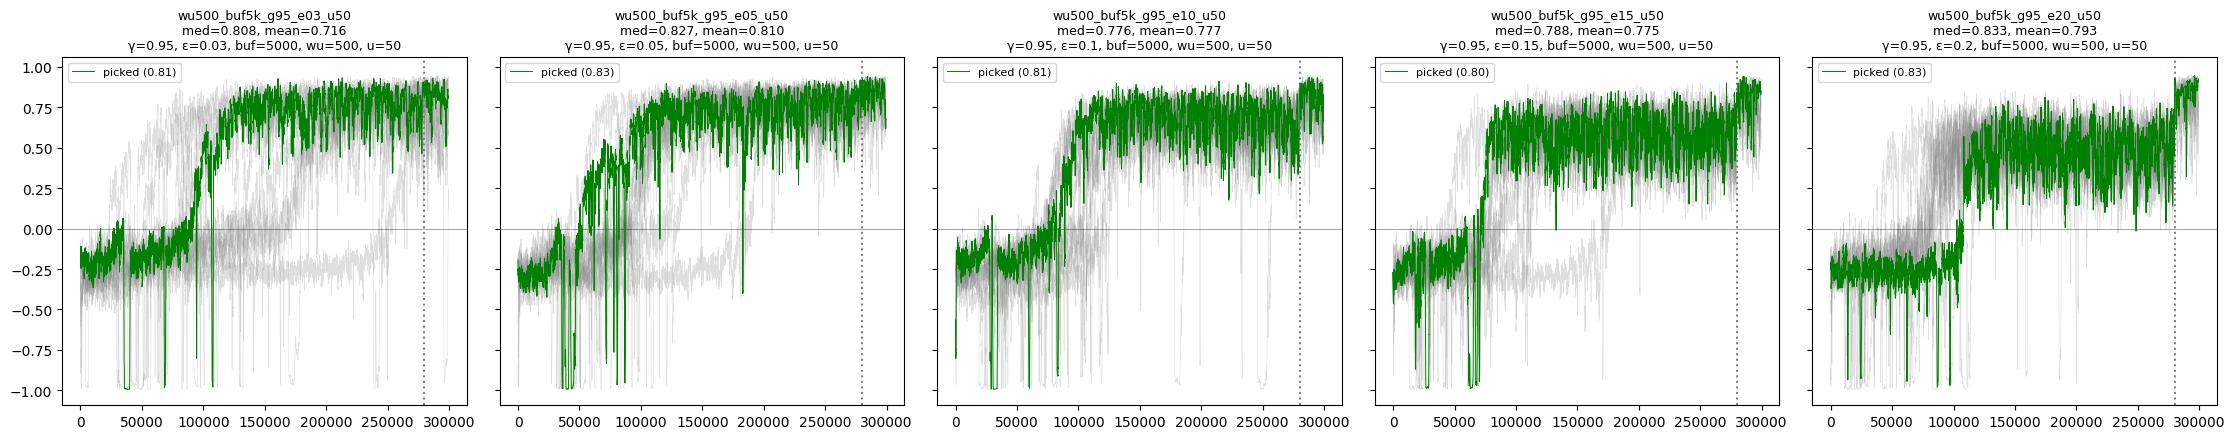

In [ ]:
#region rolling comfort — selected configs

w = 500
comp = comparison(pick="upper_median")

fig, axes = one_row_axes(len(comp), height=4.5, width_per=4.5, sharey=True)

for ax, (name, rep_run) in zip(axes, comp):
    ranked = res[name]["ranked"]

    for run in ranked:
        roll = np.convolve(run["comfort_T"], np.ones(w) / w, mode="valid")

        if run is rep_run:
            ax.plot(roll, color="green", lw=0.7, zorder=3, label=f"picked ({run['mean_comfort']:.2f})")
        else:
            ax.plot(roll, color="gray", alpha=0.25, lw=0.4)

    eb = eval_boundary(rep_run)

    ax.axvline(eb, ls=":", c="gray")
    ax.axhline(0, ls="-", c="black", lw=0.5, alpha=0.5)
    ax.set_title(config_label(name), fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#endregion

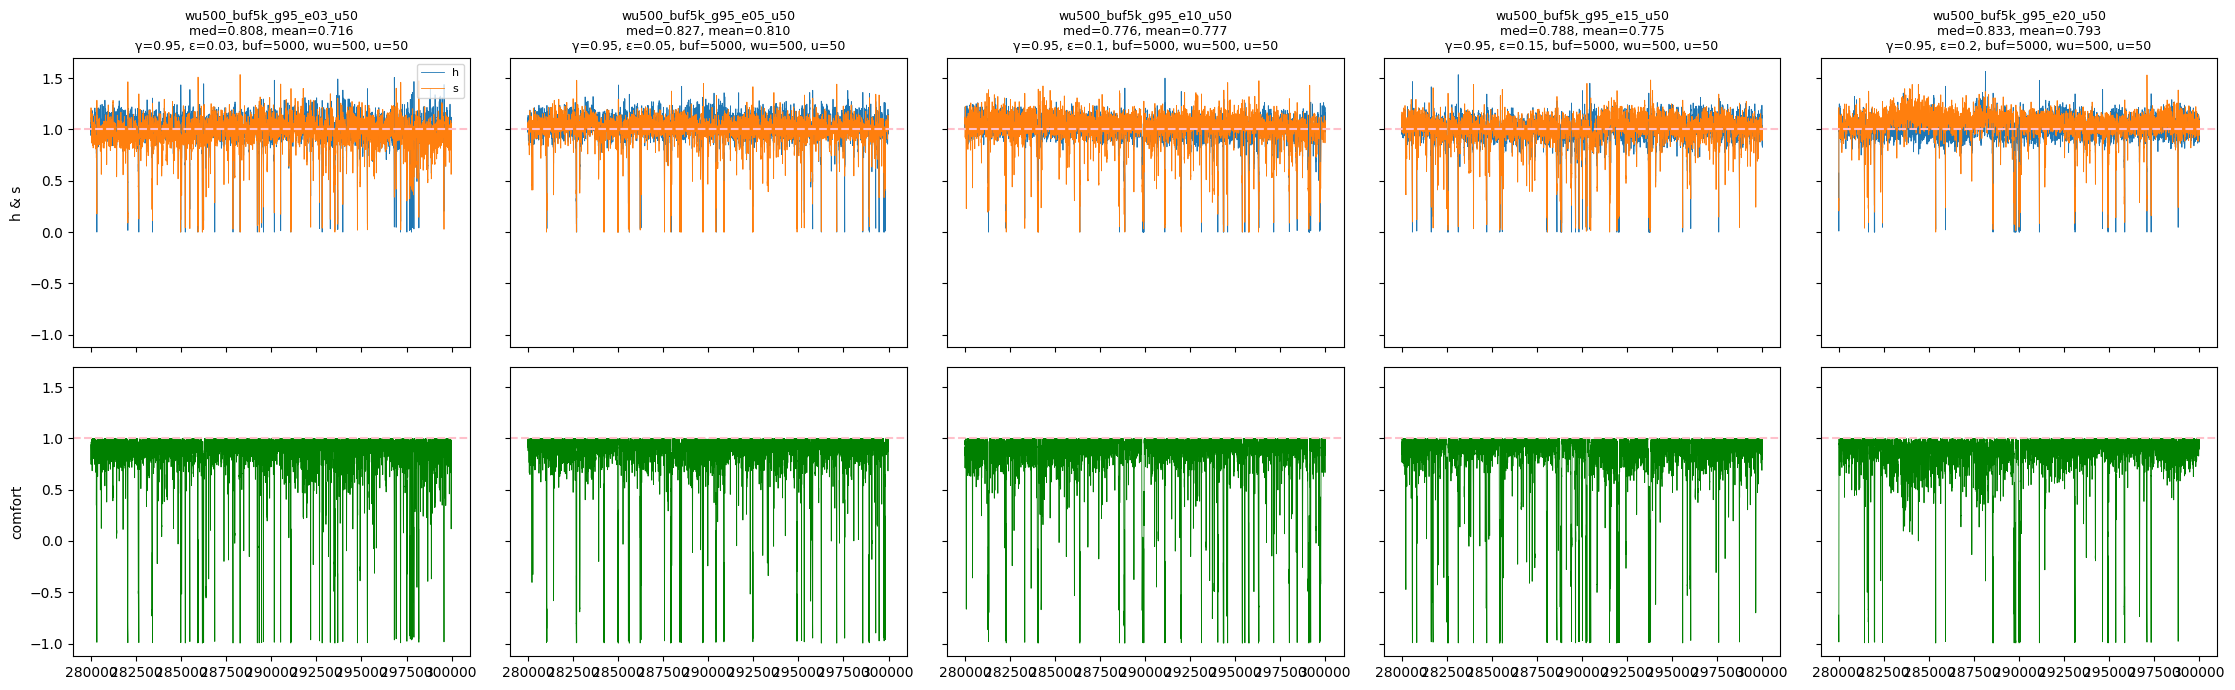

In [ ]:
#region eval h & s — selected configs

comp = comparison(pick="upper_median")

fig, axes = two_row_axes(len(comp), height=7, width_per=4.5, sharex=True, sharey=True)

for col, (name, run) in enumerate(comp):
    eb = eval_boundary(run)
    te = np.arange(eb, len(run["hydration_T"]))

    axes[0, col].plot(te, run["hydration_T"][eb:], lw=0.6, label="h", color="tab:blue")
    axes[0, col].plot(te, run["satiation_T"][eb:], lw=0.6, label="s", color="tab:orange")
    axes[0, col].axhline(1, ls="--", c="pink")
    axes[0, col].set_title(config_label(name), fontsize=9)

    axes[1, col].plot(te, run["comfort_T"][eb:], color="green", lw=0.6)
    axes[1, col].axhline(1, ls="--", c="pink")

    if col == 0:
        axes[0, col].legend(fontsize=8, loc="upper right")
        axes[0, col].set_ylabel("h & s")
        axes[1, col].set_ylabel("comfort")

plt.tight_layout()
plt.show()

#endregion

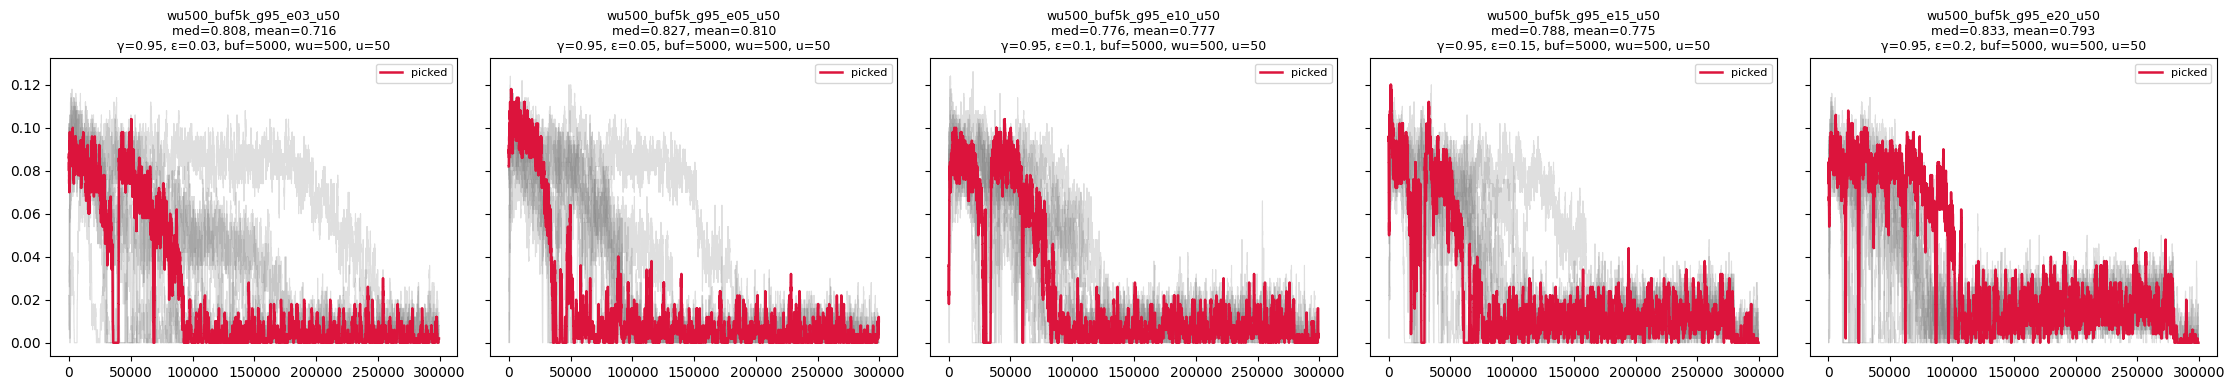

In [ ]:
#region death rate — selected configs

w = 500
comp = comparison(pick="upper_median")

fig, axes = one_row_axes(len(comp), height=4, width_per=4.5, sharey=True)

for ax, (name, rep_run) in zip(axes, comp):
    ranked = res[name]["ranked"]

    for run in ranked:
        roll = np.convolve(run["death_T"].astype(float), np.ones(w) / w, mode="valid")

        if run is rep_run:
            ax.plot(roll, color="crimson", lw=1.8, zorder=3, label="picked")
        else:
            ax.plot(roll, color="gray", alpha=0.25, lw=0.8)

    ax.set_title(config_label(name), fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#endregion

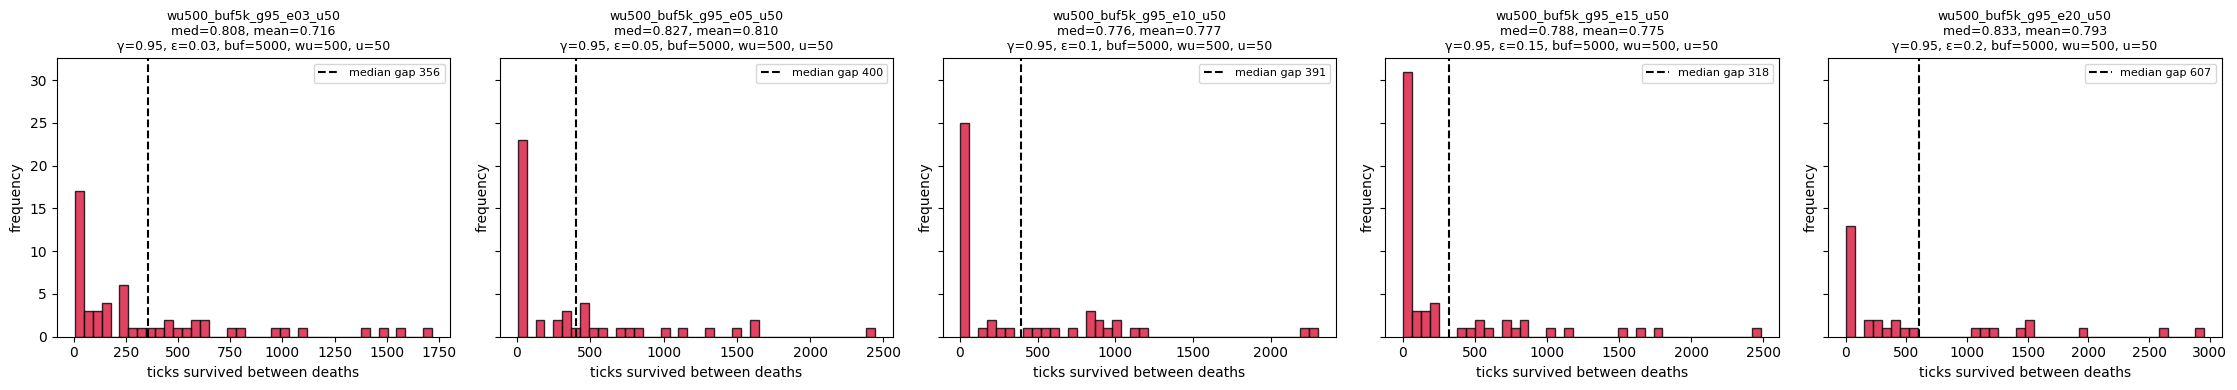

In [49]:
#region time-between-deaths histogram — selected configs

comp = comparison(pick="upper_median")

fig, axes = one_row_axes(len(comp), height=4, width_per=4.5, sharey=True)

for ax, (name, run) in zip(axes, comp):
    eb = eval_boundary(run)
    death_eval = run["death_T"][eb:]

    death_ticks = np.flatnonzero(death_eval)   # indices where a death happened
    gaps = np.diff(death_ticks)                # ticks survived between consecutive deaths

    if len(gaps) > 0:
        ax.hist(gaps, bins=40, color="crimson", edgecolor="black", alpha=0.8)
        ax.axvline(gaps.mean(), ls="--", c="black",
                   label=f"median gap {gaps.mean():.0f}")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "no deaths", ha="center", transform=ax.transAxes)

    ax.set_title(config_label(name), fontsize=9)
    ax.set_xlabel("ticks survived between deaths")
    ax.set_ylabel("frequency")

plt.tight_layout()
plt.show()

#endregion

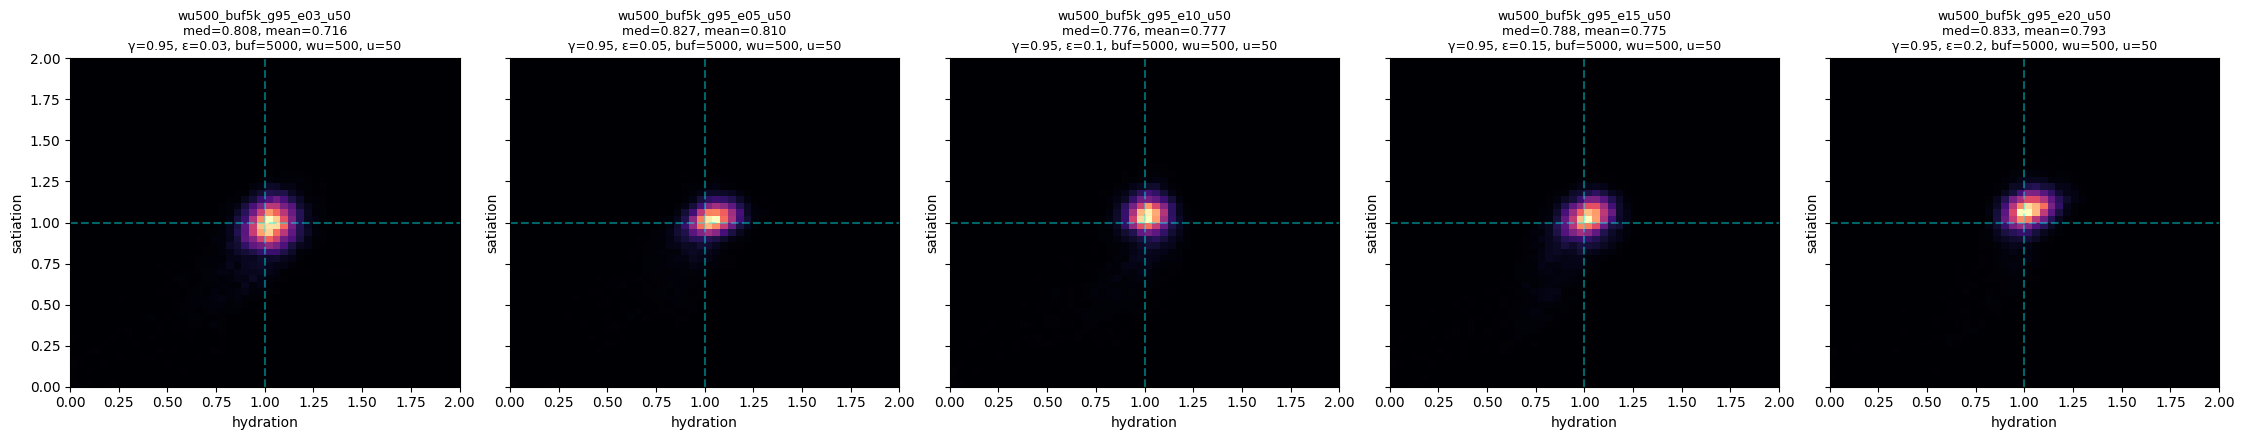

In [ ]:
#region phase portrait — selected configs

comp = comparison(pick="upper_median")

fig, axes = one_row_axes(len(comp), height=4.5, width_per=4.5, sharey=True)

for ax, (name, run) in zip(axes, comp):
    ax.hist2d(
        run["hydration_eval"],
        run["satiation_eval"],
        bins=50,
        range=[[0, 2], [0, 2]],
        cmap="magma"
    )

    ax.axvline(1, ls="--", c="cyan", alpha=0.4)
    ax.axhline(1, ls="--", c="cyan", alpha=0.4)

    ax.set_title(config_label(name), fontsize=9)
    ax.set_xlabel("hydration")
    ax.set_ylabel("satiation")

plt.tight_layout()
plt.show()

#endregion

In [ ]:
#region rolling comfort — single config quick png

w = 500
comp = comparison(pick="upper_median")

PICK_CFG = 0                     # which config from comp to plot
name, rep_run = comp[PICK_CFG]

fig, ax = plt.subplots(figsize=(4.5, 4.5))

for run in res[name]["ranked"]:
    roll = np.convolve(run["comfort_T"], np.ones(w) / w, mode="valid")
    if run is rep_run:
        ax.plot(roll, color="green", lw=0.7, zorder=3, label=f"picked ({run['mean_comfort']:.2f})")
    else:
        ax.plot(roll, color="gray", alpha=0.25, lw=0.4)

eb = eval_boundary(rep_run)
ax.axvline(eb, ls=":", c="gray")
ax.axhline(0, ls="-", c="black", lw=0.5, alpha=0.5)
ax.set_title(config_label(name), fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()

repo_root = Path.cwd().parents[1]
out_dir = repo_root / "results" / "best_figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"rolling_comfort_{name}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_path}")

plt.show()

#endregion

In [ ]:
#region GIF: 3D Comfort Hill moving eval trajectory

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

CONFIG = "wu500_buf5k_g95_e10_u50"
PICK = -1  # best run, since ranked is worst -> best

runs = res[CONFIG]["ranked"]
run = runs[PICK]

h = np.asarray(run["hydration_T"])
s = np.asarray(run["satiation_T"])
c = np.asarray(run["comfort_T"])

ideal_h, ideal_s = 1, 1
ideal_c = 1
eb = eval_boundary(run)

rank_num = PICK if PICK >= 0 else len(runs) + PICK

# Full training path, downsampled and drawn faintly
TRAIN_POINTS = 1000
train_idx = np.linspace(0, eb - 1, min(TRAIN_POINTS, eb)).astype(int)

# Eval path, downsampled for GIF
MAX_FRAMES = 260
eval_full_idx = np.arange(eb, len(h))
eval_idx = np.linspace(eb, len(h) - 1, min(MAX_FRAMES, len(eval_full_idx))).astype(int)

h_eval = h[eval_idx]
s_eval = s[eval_idx]
c_eval = c[eval_idx]

Z_LIFT = 0.1
c_eval_draw = c_eval + Z_LIFT
c_train_draw = c[train_idx] + Z_LIFT

# Short recent trail behind the dot
TRAIL = 14

grid = np.linspace(0, 2, 80)
H, S = np.meshgrid(grid, grid)
d2 = (H - ideal_h)**2 + (S - ideal_s)**2
Z = 2 * np.exp(-3 * d2) - 1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Comfort surface
ax.plot_surface(
    H, S, Z,
    alpha=0.2,
    linewidth=0,
    antialiased=True,
    cmap="viridis"
)

# Static faint training trajectory
ax.plot(
    h[train_idx], s[train_idx], c_train_draw,    
    lw=0.8,
    color="mediumpurple",
    alpha=0.18,
    label="training trajectory"
)

# Optional faint full eval path in background
ax.plot(
    h_eval, s_eval, c_eval_draw,    
    lw=0.7,
    color="gray",
    alpha=0.18,
    label="eval path"
)

# Animated short trail + dot
trail_line, = ax.plot(
    [], [], [],
    lw=2.1,
    color="gray",
    alpha=0.38,
    label="recent trail"
)

dot, = ax.plot(
    [], [], [],
    "o",
    markersize=7.5,
    color="tomato",
    alpha=0.88,
    label="current eval state"
)

# Ideal point
ax.scatter(
    [ideal_h], [ideal_s], [ideal_c],
    s=55,
    color="purple",
    alpha=0.95,
    label="ideal point"
)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_zlim(-2.2, 1.2)

ax.set_xlabel("Hydration")
ax.set_ylabel("Satiation")
ax.set_zlabel("Comfort")

ax.set_title(
    f"{CONFIG} rank {rank_num + 1}  mean_comfort={run['mean_comfort']:.3f}",
    pad=16
)


ax.view_init(elev=45, azim=-135)

ax.legend(loc="upper right")
plt.tight_layout()

def update(frame):
    start = max(0, frame - TRAIL)

    trail_line.set_data(h_eval[start:frame + 1], s_eval[start:frame + 1])
    trail_line.set_3d_properties(c_eval_draw[start:frame + 1])

    dot.set_data([h_eval[frame]], [s_eval[frame]])
    dot.set_3d_properties([c_eval_draw[frame]])

    ax.set_title(
        f"{CONFIG} rank {rank_num + 1}  "
        f"mean_comfort={run['mean_comfort']:.3f}  "
        f"eval frame {frame + 1}/{len(h_eval)}",
        pad=16
    )

    return trail_line, dot

anim = FuncAnimation(
    fig,
    update,
    frames=len(h_eval),
    interval=45,
    blit=False
)

repo_root = Path.cwd().parents[1]
out_dir = repo_root / "results" / "best_figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"comfort_hill_3d_eval_{CONFIG}_rank{rank_num + 1}.gif"

anim.save(out_path, writer=PillowWriter(fps=22))
plt.close(fig)

display(Image(filename=str(out_path)))
print(f"Saved GIF to: {out_path}")

#endregion

In [ ]:
#region eval h & s — single config quick png

comp = comparison(pick="upper_median")

PICK_CFG = 0                     # which config from comp to plot
name, run = comp[PICK_CFG]

eb = eval_boundary(run)
te = np.arange(eb, len(run["hydration_T"]))

fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.plot(te, run["hydration_T"][eb:], lw=0.3, alpha=0.7, label="h", color="tab:blue")
ax.plot(te, run["satiation_T"][eb:], lw=0.3, alpha=0.7, label="s", color="tab:orange")
ax.axhline(1, ls="--", c="pink")
ax.set_title(config_label(name), fontsize=9)
ax.set_ylabel("h & s")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()

repo_root = Path.cwd().parents[1]
out_dir = repo_root / "results" / "best_figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"eval_hs_{name}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_path}")

plt.show()

#endregion

In [39]:
#Path.cwd()

In [ ]:
#region GIF: 2D phase trajectory for one selected run
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# Pick from the same comparison batch used in your 5-panel plot
comp = comparison(pick="upper_median")

# Choose which panel/run to animate
# 0 = first config in comp, 1 = second, etc.
PICK_PANEL = 0

name, run = comp[PICK_PANEL]

h = np.asarray(run["hydration_eval"])
s = np.asarray(run["satiation_eval"])

# Downsample so the GIF is not enormous
MAX_FRAMES = 350
idx = np.linspace(0, len(h) - 1, min(MAX_FRAMES, len(h))).astype(int)

h_anim = h[idx]
s_anim = s[idx]

# How much recent movement to show behind the dot
TRAIL = 30

repo_root = Path.cwd().parents[1]
out_dir = repo_root / "results" / "best_figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"phase_trajectory_{name}.gif"

fig, ax = plt.subplots(figsize=(6, 6))

# Background density from the full evaluation run
ax.hist2d(
    h,
    s,
    bins=50,
    range=[[0, 2], [0, 2]],
    cmap="magma"
)

ax.axvline(1, ls="--", c="cyan", alpha=0.45)
ax.axhline(1, ls="--", c="cyan", alpha=0.45)
ax.scatter([1], [1], c="cyan", s=45, label="ideal point")

trail_line, = ax.plot([], [], lw=2.2, color="silver", alpha=0.35)
dot, = ax.plot([], [], "o", markersize=7.5, color="orangered", alpha=0.85)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xlabel("hydration")
ax.set_ylabel("satiation")
ax.set_title(f"{config_label(name)} — evaluation trajectory")

def init():
    trail_line.set_data([], [])
    dot.set_data([], [])
    return trail_line, dot

def update(frame):
    start = max(0, frame - TRAIL)

    trail_line.set_data(h_anim[start:frame+1], s_anim[start:frame+1])
    dot.set_data([h_anim[frame]], [s_anim[frame]])

    ax.set_title(
        f"{config_label(name)} — eval trajectory "
        f"frame {frame+1}/{len(h_anim)}"
    )

    return trail_line, dot

anim = FuncAnimation(
    fig,
    update,
    frames=len(h_anim),
    init_func=init,
    interval=45,
    blit=True
)

anim.save(out_path, writer=PillowWriter(fps=22))
plt.close(fig)

display(Image(filename=str(out_path)))

print(f"Saved GIF to: {out_path}")

#endregion